# Final Project: การจำแนกโรคหัวใจจากข้อมูล UCI Heart Disease

> 2569-คณิตศาสตร์สำหรับวิทยาการข้อมูล

**กลุ่ม:**
- สมาชิกที่ 1: นายนัธทวัฒน์ เขาแก้ว (68114540337)
- สมาชิกที่ 2: นายปรีชา แสงแก้ว (68114540382)

**Dataset:** UCI Heart Disease (ID 45), ไฟล์ `dataset_heart_disease.xlsx` sheet `data` (920 แถว รวม 4 institution)  
https://archive.ics.uci.edu/dataset/45/heart+disease

**Problem Statement:** ชุดข้อมูลบันทึกอาการและผลตรวจผู้ป่วยจาก Cleveland, Hungarian, VA และ Switzerland เราต้องการจำแนกว่ามีโรคหัวใจหรือไม่ โดยใช้ `num > 0` เป็นคลาส ข้อมูลมี missing ในบางคอลัมน์และสัดส่วนคลาสใกล้ 55:45 จึงทำ EDA ก่อนสร้างโมเดล

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ✅ |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

C_NO = "#3D7EA6"
C_YES = "#C75146"
C_TRAIN = "#3D7EA6"
C_TEST = "#C75146"
C_ACCENT = "#2D6A4F"
PALETTE_CV = ["#3D7EA6", "#6B9080", "#C75146"]

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.35,
})

DATA_PATH = Path("dataset_heart_disease.xlsx")

---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix


In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="data")
print(f"Shape: {df.shape}")
print(df.dtypes)
print("\nMissing (top):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

clinical = [c for c in ["age", "sex", "cp", "trestbps", "chol", "thalach", "oldpeak", "num"] if c in df.columns]
print("\nDescribe (clinical columns):")
display(df[clinical].describe().round(2))

df.head()

Shape: (920, 44)
institution      object
age               int64
sex               int64
cp                int64
trestbps        float64
chol            float64
fbs             float64
restecg         float64
thalach         float64
exang           float64
oldpeak         float64
slope           float64
ca              float64
thal            float64
num               int64
sex_0             int64
sex_1             int64
cp_1              int64
cp_2              int64
cp_3              int64
cp_4              int64
fbs_0             int64
fbs_1             int64
fbs_<NA>          int64
restecg_0         int64
restecg_1         int64
restecg_2         int64
restecg_<NA>      int64
exang_0           int64
exang_1           int64
exang_<NA>        int64
slope_1           int64
slope_2           int64
slope_3           int64
slope_<NA>        int64
ca_0              int64
ca_1              int64
ca_2              int64
ca_3              int64
ca_<NA>           int64
thal_3            int64

,age,sex,cp,trestbps,chol,thalach,oldpeak,num
count,920.00,920.00,920.00,861.00,890.00,865.00,858.00,920.00
mean,53.51,0.79,3.25,132.13,199.13,137.55,0.88,1.00
std,9.42,0.41,0.93,19.07,110.78,25.93,1.09,1.14
min,28.00,0.00,1.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,1.00,3.00,120.00,175.00,120.00,0.00,0.00
50%,54.00,1.00,4.00,130.00,223.00,140.00,0.50,1.00
75%,60.00,1.00,4.00,140.00,268.00,157.00,1.50,2.00
max,77.00,1.00,4.00,200.00,603.00,202.00,6.20,4.00


,institution,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,...,slope_<NA>,ca_0,ca_1,ca_2,ca_3,ca_<NA>,thal_3,thal_6,thal_7,thal_<NA>
0,cleveland,63,1,1,145.0,233.0,1.0,2.0,150.0,0.0,...,0,1,0,0,0,0,0,1,0,0
1,cleveland,67,1,4,160.0,286.0,0.0,2.0,108.0,1.0,...,0,0,0,0,1,0,1,0,0,0
2,cleveland,67,1,4,120.0,229.0,0.0,2.0,129.0,1.0,...,0,0,0,1,0,0,0,0,1,0
3,cleveland,37,1,3,130.0,250.0,0.0,0.0,187.0,0.0,...,0,1,0,0,0,0,1,0,0,0
4,cleveland,41,0,2,130.0,204.0,0.0,2.0,172.0,0.0,...,0,1,0,0,0,0,1,0,0,0


Target disease=1: 0.553 (509/920)

Feature summary (first 8 columns):
             mean      std   min    max
age        53.511    9.425  28.0   77.0
sex         0.789    0.408   0.0    1.0
cp          3.250    0.931   1.0    4.0
trestbps  131.996   18.451   0.0  200.0
chol      199.909  109.040   0.0  603.0
fbs         0.150    0.357   0.0    1.0
restecg     0.603    0.805   0.0    2.0
thalach   137.692   25.145  60.0  202.0


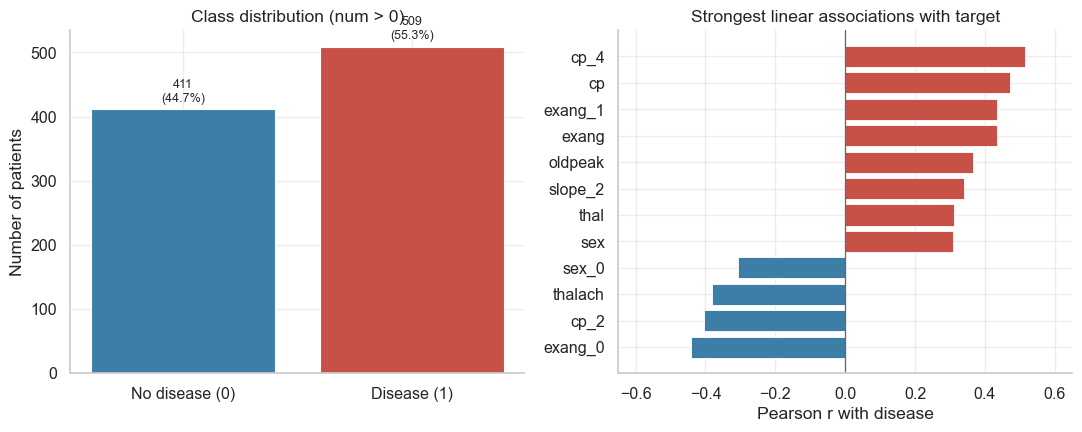


Records per institution:
institution
cleveland        303
hungarian        294
va_long_beach    200
switzerland      123
Name: count, dtype: int64


In [3]:
y = (df["num"] > 0).astype(int)
feature_cols = [c for c in df.columns if c not in ("institution", "num")]
X_df = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X_df = X_df.fillna(X_df.median())

print("Target disease=1:", y.mean().round(3), f"({y.sum()}/{len(y)})")
print("\nFeature summary (first 8 columns):")
print(X_df.describe().T[["mean", "std", "min", "max"]].head(8).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
counts = y.value_counts().sort_index()
class_labels = ["No disease (0)", "Disease (1)"]
n_total = counts.sum()
axes[0].bar(
    class_labels,
    counts.values,
    color=[C_NO, C_YES],
    edgecolor="white",
    linewidth=0.8,
)
axes[0].set_title("Class distribution (num > 0)")
axes[0].set_ylabel("Number of patients")
for i, v in enumerate(counts.values):
    pct = 100 * v / n_total
    axes[0].text(i, v + 8, f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

corr_tgt = X_df.assign(disease=y).corr(numeric_only=True)["disease"].drop("disease")
top_idx = corr_tgt.abs().sort_values(ascending=False).head(12).index
top_corr = corr_tgt.loc[top_idx].sort_values()
bar_colors = [C_YES if v > 0 else C_NO for v in top_corr.values]
axes[1].barh(top_corr.index, top_corr.values, color=bar_colors, edgecolor="white", linewidth=0.6)
axes[1].axvline(0, color="0.4", linewidth=0.9)
axes[1].set_xlabel("Pearson r with disease")
axes[1].set_title("Strongest linear associations with target")
axes[1].set_xlim(-0.65, 0.65)
plt.tight_layout()
plt.show()

print("\nRecords per institution:")
print(df["institution"].value_counts())

หลังโหลดข้อมูลได้ 920 แถว 44 คอลัมน์ แบ่งตาม institution เป็น cleveland 303, hungarian 294, va_long_beach 200, switzerland 123 คอลัมน์ `ca` และ `thal` มี missing มากที่สุด คลาส disease=1 อยู่ที่ 509/920 กราฟด้านขวาแสดง Pearson r ของฟีเจอร์กับ target ช่วยเลือกตัวแปรที่น่าสนใจก่อนโมเดล

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** เลือก Task A ทำ PCA จาก covariance matrix ด้วย `np.linalg.eigh` เพราะมีฟีเจอร์หลายคอลัมน์หลัง one-hot อยากดูว่า variance กระจุกในไม่กี่ component


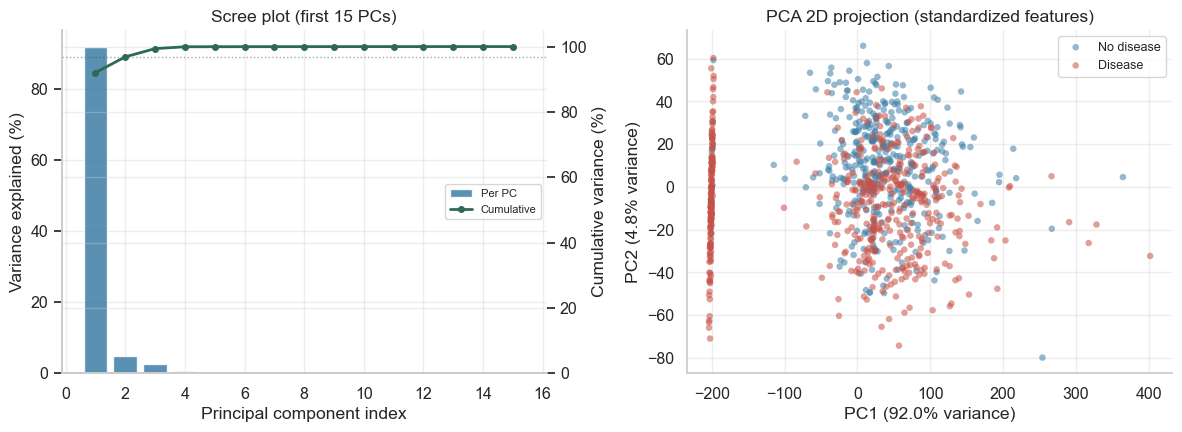

PC1+PC2 variance: 96.8%
Top |loadings| on PC1:
chol        0.998345
thalach     0.054777
trestbps    0.015255
age         0.007786
thal        0.001541
dtype: float64


In [4]:
X = X_df.values.astype(float)
X_mean = X.mean(axis=0)
Xc = X - X_mean
n = X.shape[0]
C = (Xc.T @ Xc) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained = eigenvalues / eigenvalues.sum()
cum = np.cumsum(explained)
X_pca2 = Xc @ eigenvectors[:, :2]

k_show = min(15, len(explained))
pcs = np.arange(1, k_show + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax_s = axes[0]
ax_s.bar(pcs, explained[:k_show] * 100, color=C_NO, alpha=0.85, label="Per PC")
ax_s.set_xlabel("Principal component index")
ax_s.set_ylabel("Variance explained (%)")
ax_s.set_title("Scree plot (first 15 PCs)")
ax_cum = ax_s.twinx()
ax_cum.plot(pcs, cum[:k_show] * 100, color=C_ACCENT, marker="o", ms=4, lw=2, label="Cumulative")
ax_cum.set_ylabel("Cumulative variance (%)")
ax_cum.set_ylim(0, 105)
ax_cum.axhline(cum[1] * 100, color=C_ACCENT, linestyle=":", alpha=0.5, lw=1)
h1, l1 = ax_s.get_legend_handles_labels()
h2, l2 = ax_cum.get_legend_handles_labels()
ax_s.legend(h1 + h2, l1 + l2, loc="center right", fontsize=8)

mask0, mask1 = y == 0, y == 1
axes[1].scatter(
    X_pca2[mask0, 0], X_pca2[mask0, 1],
    c=C_NO, alpha=0.55, s=22, label="No disease", edgecolors="none",
)
axes[1].scatter(
    X_pca2[mask1, 0], X_pca2[mask1, 1],
    c=C_YES, alpha=0.55, s=22, label="Disease", edgecolors="none",
)
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
axes[1].set_title("PCA 2D projection (standardized features)")
axes[1].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"PC1+PC2 variance: {cum[1]*100:.1f}%")
load = pd.Series(eigenvectors[:, 0], index=feature_cols).abs().sort_values(ascending=False)
print("Top |loadings| on PC1:")
print(load.head(5))

**Insight จาก CLO1 Analysis:**

- PC1+PC2 รวม variance ได้ 96.8% แสดงว่าข้อมูลหลัง one-hot อยู่ใน subspace ไม่กี่มิติ
- กราฟ projection 2D จุดสองคลาสยังปนกัน แยกด้วย PCA สองแกนอย่างเดียวยาก
- loading ของ PC1 มีฟีเจอร์ dummy หลายตัวสูง สอดคล้องกับความซ้ำซ้อนของ one-hot


---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

**คำตอบ:** เหมาะกับ **Classification** เพราะเป้าหมายคือมีโรคหัวใจหรือไม่ เราแปลง `num` เป็น 0/1 ส่วน polynomial regression ของ `age` กับ `num` ใช้ดู bias-variance ตามโจทย์ CLO2


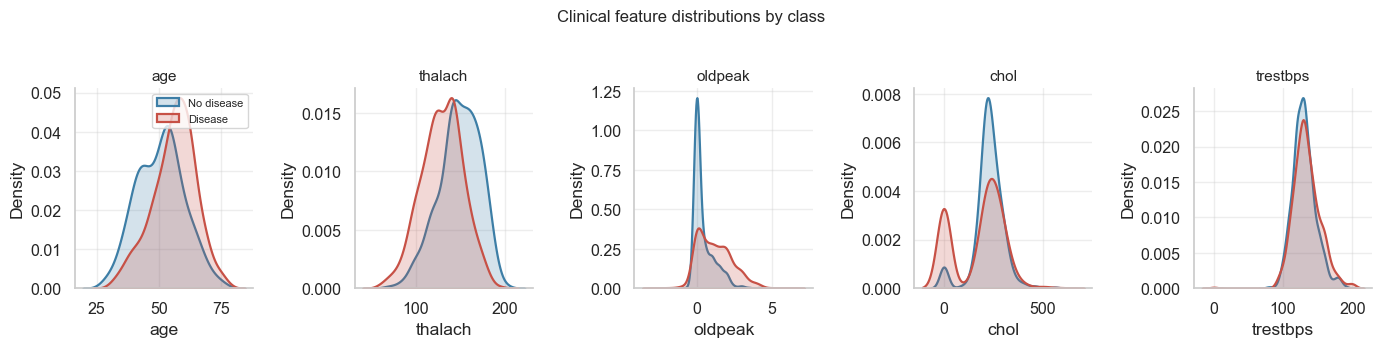

Correlation with disease (top 5):
cp_4       0.516
cp         0.472
exang_0    0.443
exang_1    0.434
exang      0.434
Name: disease, dtype: float64


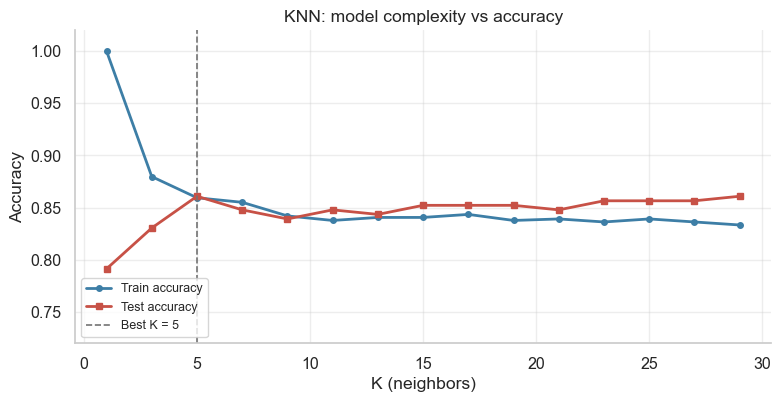

Best K on this split: 5 (test acc 0.861)


In [5]:
key_feats = ["age", "thalach", "oldpeak", "chol", "trestbps"]
fig, axes = plt.subplots(1, len(key_feats), figsize=(14, 3.4), sharey=False)
for ax, col in zip(axes, key_feats):
    for cls, color, label in [(0, C_NO, "No disease"), (1, C_YES, "Disease")]:
        sns.kdeplot(
            X_df.loc[y == cls, col],
            ax=ax,
            color=color,
            fill=True,
            alpha=0.22,
            linewidth=1.6,
            label=label,
        )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8, loc="upper right")
plt.suptitle("Clinical feature distributions by class", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

corr_tgt = X_df.assign(disease=y).corr(numeric_only=True)["disease"].drop("disease").abs().sort_values(ascending=False)
print("Correlation with disease (top 5):")
print(corr_tgt.head(5).round(3))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

ks = list(range(1, 31, 2))
tr_acc, te_acc = [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_s, y_tr)
    tr_acc.append(accuracy_score(y_tr, knn.predict(X_tr_s)))
    te_acc.append(accuracy_score(y_te, knn.predict(X_te_s)))

best_k = ks[int(np.argmax(te_acc))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ks, tr_acc, color=C_TRAIN, marker="o", ms=4, lw=2, label="Train accuracy")
ax.plot(ks, te_acc, color=C_TEST, marker="s", ms=4, lw=2, label="Test accuracy")
ax.axvline(best_k, color="0.45", linestyle="--", lw=1.2, label=f"Best K = {best_k}")
ax.set_xlabel("K (neighbors)")
ax.set_ylabel("Accuracy")
ax.set_title("KNN: model complexity vs accuracy")
ax.set_ylim(0.72, 1.02)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Best K on this split: {best_k} (test acc {max(te_acc):.3f})")

**Polynomial regression:** ใช้ `age` ทำนาย `num` ตาม degree 1–15 แล้วเปรียบเทียบ train/test MSE


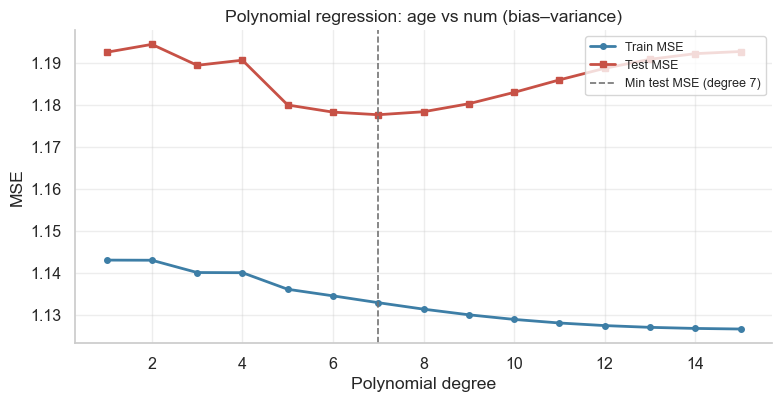

Lowest test MSE at degree 7 (MSE=1.178)


In [6]:
age = df["age"].values.reshape(-1, 1)
t_num = df["num"].values.astype(float)
age_tr, age_te, num_tr, num_te = train_test_split(age, t_num, test_size=0.25, random_state=42)

degrees = list(range(1, 16))
tr_mse, te_mse = [], []
for d in degrees:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression()),
    ])
    pipe.fit(age_tr, num_tr)
    tr_mse.append(mean_squared_error(num_tr, pipe.predict(age_tr)))
    te_mse.append(mean_squared_error(num_te, pipe.predict(age_te)))

best_d = degrees[int(np.argmin(te_mse))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(degrees, tr_mse, color=C_TRAIN, marker="o", ms=4, lw=2, label="Train MSE")
ax.plot(degrees, te_mse, color=C_TEST, marker="s", ms=4, lw=2, label="Test MSE")
ax.axvline(best_d, color="0.45", linestyle="--", lw=1.2, label=f"Min test MSE (degree {best_d})")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("Polynomial regression: age vs num (bias–variance)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Lowest test MSE at degree {best_d} (MSE={min(te_mse):.3f})")

**Insight จาก CLO2 Analysis:**

- ฟีเจอร์ที่ correlate กับ disease สูงสุดใน train ได้แก่ `cp_4` (0.516) และ `exang` ราว 0.43–0.44
- polynomial: test MSE ต่ำสุดที่ degree 7 (MSE=1.178) หลัง degree สูงมาก test MSE สูงขึ้น
- KNN: K=1 overfit train=1.0 บน split นี้ K=5 ได้ test accuracy สูงสุด 0.861


---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** Classification


Logistic Regression
  Train accuracy: 0.829
  Test accuracy:  0.835

Top |coefficient| (scaled features):
  ca_0           -0.445
  oldpeak        +0.348
  slope_2        +0.335
  cp_2           -0.307
  cp_4           +0.300
  fbs_<NA>       +0.298
  age            +0.257
  ca_<NA>        +0.254
  thal_7         +0.244
  cp             +0.239


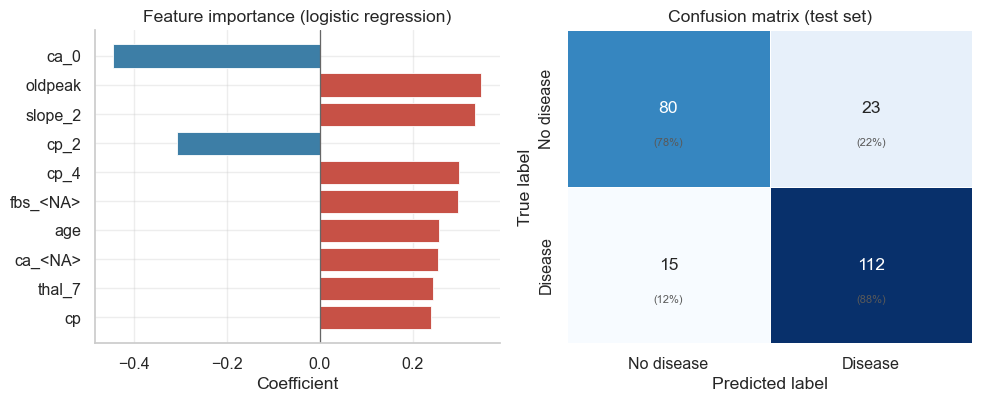

In [7]:
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])
logit_pipe.fit(X_tr, y_tr)
pred_tr = logit_pipe.predict(X_tr)
pred_te = logit_pipe.predict(X_te)
acc_tr_log = accuracy_score(y_tr, pred_tr)
acc_te_log = accuracy_score(y_te, pred_te)

print("Logistic Regression")
print(f"  Train accuracy: {acc_tr_log:.3f}")
print(f"  Test accuracy:  {acc_te_log:.3f}")

coefs = logit_pipe.named_steps["clf"].coef_[0]
order = np.argsort(np.abs(coefs))[::-1][:10]
print("\nTop |coefficient| (scaled features):")
for j in order:
    print(f"  {feature_cols[j]:14s} {coefs[j]:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
top_names = [feature_cols[j] for j in order]
top_coefs = coefs[order]
colors = [C_YES if c > 0 else C_NO for c in top_coefs]
axes[0].barh(top_names[::-1], top_coefs[::-1], color=colors[::-1], edgecolor="white", linewidth=0.6)
axes[0].axvline(0, color="0.4", linewidth=0.9)
axes[0].set_xlabel("Coefficient")
axes[0].set_title("Feature importance (logistic regression)")

cm = confusion_matrix(y_te, pred_te)
cm_row = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1],
    xticklabels=["No disease", "Disease"],
    yticklabels=["No disease", "Disease"],
    linewidths=0.6,
    linecolor="white",
)
for i in range(2):
    for j in range(2):
        axes[1].text(j + 0.5, i + 0.72, f"({cm_row[i, j]*100:.0f}%)", ha="center", va="center", fontsize=8, color="0.35")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

KNN (K=11)


  Train accuracy: 0.838
  Test accuracy:  0.848


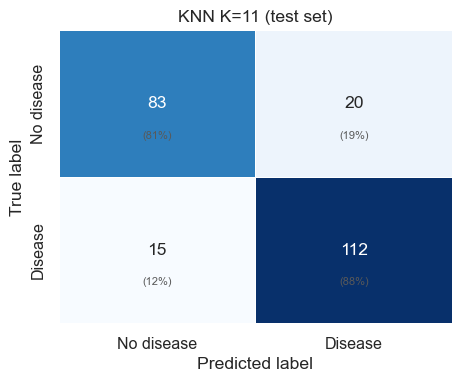

In [8]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=11)),
])
knn_pipe.fit(X_tr, y_tr)
pred_te_knn = knn_pipe.predict(X_te)
acc_tr_knn = accuracy_score(y_tr, knn_pipe.predict(X_tr))
acc_te_knn = accuracy_score(y_te, pred_te_knn)

print("KNN (K=11)")
print(f"  Train accuracy: {acc_tr_knn:.3f}")
print(f"  Test accuracy:  {acc_te_knn:.3f}")

fig, ax = plt.subplots(figsize=(4.8, 4))
cm = confusion_matrix(y_te, pred_te_knn)
cm_row = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax,
    xticklabels=["No disease", "Disease"],
    yticklabels=["No disease", "Disease"],
    linewidths=0.6,
    linecolor="white",
)
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, f"({cm_row[i, j]*100:.0f}%)", ha="center", va="center", fontsize=8, color="0.35")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("KNN K=11 (test set)")
plt.tight_layout()
plt.show()

Model comparison train/test 25%



,Model,Train accuracy,Test accuracy,Train − test gap
0,Logistic Regression,0.829,0.835,-0.006
1,KNN (K=11),0.838,0.848,-0.010


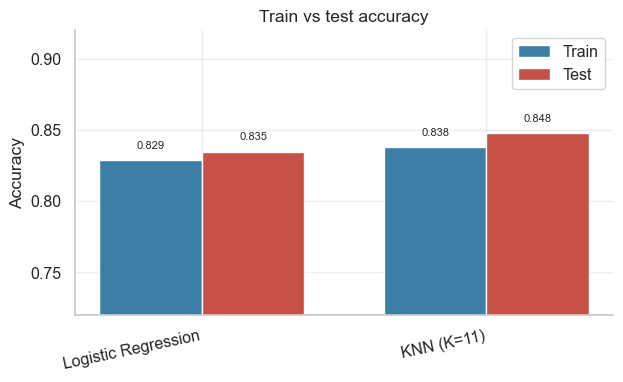

Higher test accuracy on this split: KNN (K=11)



| Model | Train accuracy | Test accuracy | Train − test |
|-------|----------------|---------------|--------------|
| Logistic Regression | 0.829 | 0.835 | -0.006 |
| KNN (K=11) | 0.838 | 0.848 | -0.010 |


In [9]:
cmp = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN (K=11)"],
    "Train accuracy": [acc_tr_log, acc_tr_knn],
    "Test accuracy": [acc_te_log, acc_te_knn],
})
cmp["Train − test gap"] = (cmp["Train accuracy"] - cmp["Test accuracy"]).round(3)
cmp_display = cmp.copy()
for col in ["Train accuracy", "Test accuracy"]:
    cmp_display[col] = cmp_display[col].map(lambda x: f"{x:.3f}")
print("Model comparison train/test 25%\n")
display(cmp_display)

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(cmp))
w = 0.36
ax.bar(x - w / 2, cmp["Train accuracy"], w, label="Train", color=C_TRAIN)
ax.bar(x + w / 2, cmp["Test accuracy"], w, label="Test", color=C_TEST)
ax.set_xticks(x)
ax.set_xticklabels(cmp["Model"], rotation=12, ha="right")
ax.set_ylim(0.72, 0.92)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs test accuracy")
ax.legend()
for i, row in cmp.iterrows():
    ax.text(i - w / 2, row["Train accuracy"] + 0.008, f"{row['Train accuracy']:.3f}", ha="center", fontsize=8)
    ax.text(i + w / 2, row["Test accuracy"] + 0.008, f"{row['Test accuracy']:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

better = "KNN (K=11)" if acc_te_knn >= acc_te_log else "Logistic Regression"
print(f"Higher test accuracy on this split: {better}")
from IPython.display import Markdown

md_table = f"""
| Model | Train accuracy | Test accuracy | Train − test |
|-------|----------------|---------------|--------------|
| Logistic Regression | {acc_tr_log:.3f} | {acc_te_log:.3f} | {acc_tr_log - acc_te_log:.3f} |
| KNN (K=11) | {acc_tr_knn:.3f} | {acc_te_knn:.3f} | {acc_tr_knn - acc_te_knn:.3f} |
"""
display(Markdown(md_table))

**Insight จาก CLO3 Analysis:**

- แบ่ง train/test 75/25 stratified Logistic test accuracy 0.835 และ KNN K=11 ได้ 0.848
- coefficient ของ logistic ที่เด่นคือ `oldpeak`, `cp`, `ca` สอดคล้องกับ correlation ใน Part 3
- confusion matrix ช่วยดูว่าพลาดคลาส 0 หรือ 1 บ่อยกว่า


---
## Part 5: CLO4 — Model Selection

ใช้ 5-fold cross-validation เปรียบเทียบ Logistic, Logistic C=0.1 และ KNN-15 ใน Pipeline ที่มี StandardScaler


Logistic: CV accuracy = 0.792 (+/- 0.111)

Logistic C=0.1: CV accuracy = 0.791 (+/- 0.109)
KNN-15: CV accuracy = 0.803 (+/- 0.085)


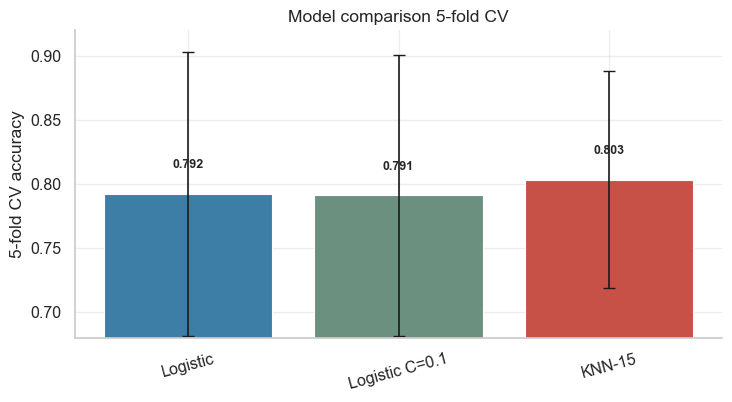

Best by CV: KNN-15 (0.803)


In [10]:
models = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "Logistic C=0.1": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=42, C=0.1)),
    ]),
    "KNN-15": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15)),
    ]),
}

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_scores[name] = scores
    print(f"{name}: CV accuracy = {scores.mean():.3f} (+/- {scores.std():.3f})")

names = list(models.keys())
means = [cv_scores[k].mean() for k in names]
stds = [cv_scores[k].std() for k in names]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(names, means, color=PALETTE_CV, edgecolor="white", linewidth=0.8, yerr=stds, capsize=4, error_kw={"elinewidth": 1.2})
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Model comparison 5-fold CV")
ax.set_ylim(0.68, 0.92)
ax.tick_params(axis="x", rotation=15)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.02, f"{m:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

best = max(names, key=lambda k: cv_scores[k].mean())
print("Best by CV:", best, f"({cv_scores[best].mean():.3f})")

**Best Model จาก Cross-Validation:** KNN-15 ได้ CV accuracy 0.803 สูงกว่า Logistic 0.792 และ Logistic C=0.1 ที่ 0.791

ใช้ Pipeline ใน CV เพื่อ fit StandardScaler แยกในแต่ละ fold ไม่ให้ข้อมูลของ fold test หลุดเข้า scaler ก่อนเวลา


---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
- **CLO1:** PCA ยุบ variance ได้ในไม่กี่ component แต่ 2D แยกคลาสไม่ชัด
- **CLO2:** ฟีเจอร์ chest pain และ exercise angina สัมพันธ์กับ disease ชัด polynomial และ K แสดง trade-off complexity
- **CLO3:** Logistic กับ KNN ได้ test accuracy 0.835 และ 0.848 บน hold-out 25%
- **CLO4:** 5-fold CV เลือก KNN-15 เป็นตัวที่ accuracy เฉลี่ยดีที่สุดในโมเดลที่ลอง
- **Data story:** อาการและผลตรวจบางตัวช่วยจำแนกได้ระดับ ~80–85% แต่ยังพลาดได้ทั้งสองคลาส ข้อมูลรวมหลายโรงพยาบาลจึงไม่ควรเอาไปใช้วินิจฉัยจริง

**6.2 Limitations:**
- ข้อมูล UCI ไม่ใช่คนไทย มี missing ที่ ca, thal และใช้ median impute ทั้งตาราง
- แบ่ง test แบบสุ่มครั้งเดียว ค่า accuracy อาจเปลี่ยนเล็กน้อยถ้า seed ต่างกัน

**6.3 ขั้นตอนต่อไป:**
- ลองจำแนก `num` แบบหลายระดับ หรือดู ROC/AUC
- ทดลอง impute แยกตาม institution

**6.4 Connection กับ Topics ในวิชา:**
- Week 4: covariance, eigenvalues, PCA
- Week 6: bias-variance, polynomial regression
- Week 11–12: logistic regression, KNN
- Week 14: cross-validation, Pipeline

**Acknowledgements:** UCI Heart Disease dataset, scikit-learn
